In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles

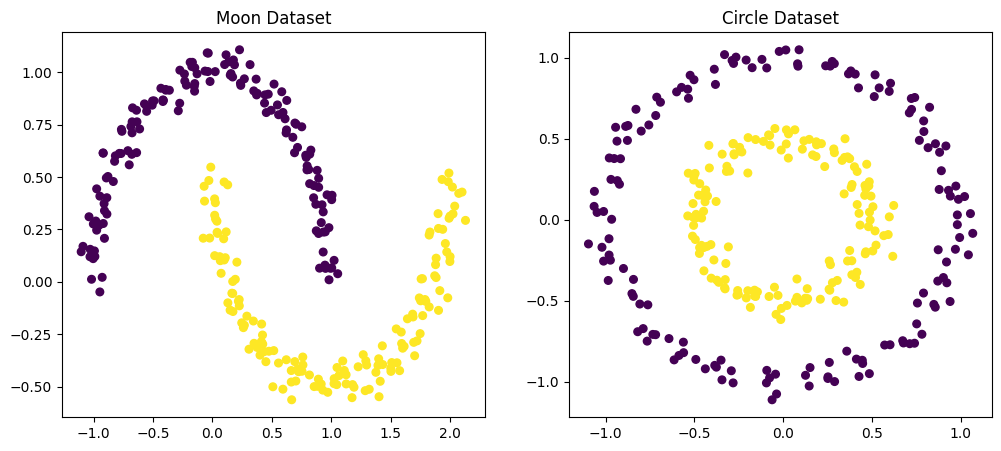

In [15]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="viridis", s=30)
axes[0].set_title("Moon Dataset")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="viridis", s=30)
axes[1].set_title("Circle Dataset")

plt.show()

Text(0.5, 1.0, 'K_means on Circle')

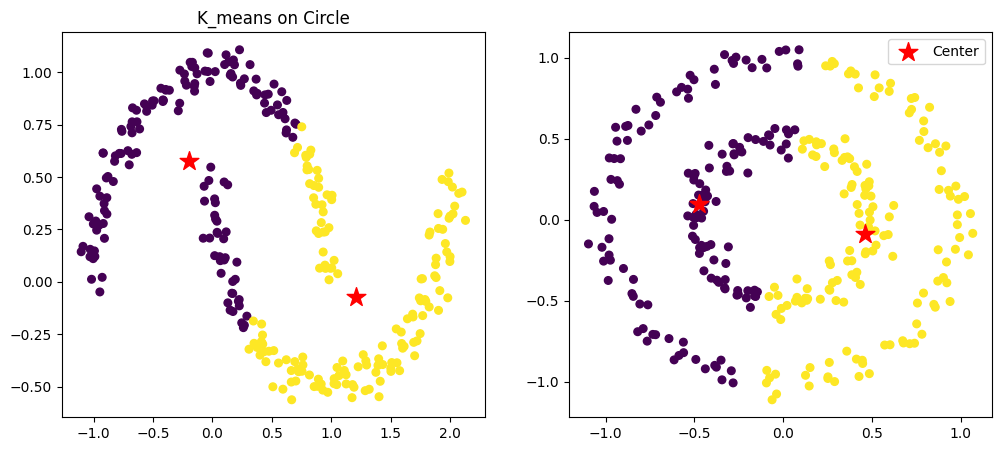

In [22]:
from sklearn.cluster import KMeans

kmeans_moons = KMeans(n_clusters=2, random_state=42)
y_kmeans_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=42)
y_kmeans_circles = kmeans_circles.fit_predict(X_circles)

fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_kmeans_moons, cmap="viridis", s=30)
axes[0].scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:,1], c='red', marker="*", s=200, label="Center")
axes[0].set_title("K_means on Moon")


axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_kmeans_circles, cmap="viridis", s=30)
axes[1].scatter(kmeans_circles.cluster_centers_[:, 0], kmeans_circles.cluster_centers_[:,1], c='red', marker="*", s=200, label="Center")
axes[1].legend()
axes[0].set_title("K_means on Circle")



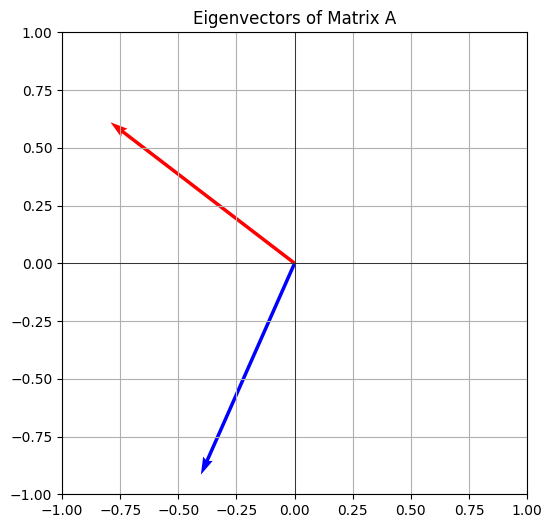

In [3]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[2, 4], [7, 8]])
eig_vals, eig_vecs = np.linalg.eig(A)

X = [0, 0]
Y = [0, 0]

U = eig_vecs[0, :]
V = eig_vecs[1, :]

plt.figure(figsize=(6, 6))
plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color=['r', 'b'])

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.title("Eigenvectors of Matrix A")
plt.show()


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


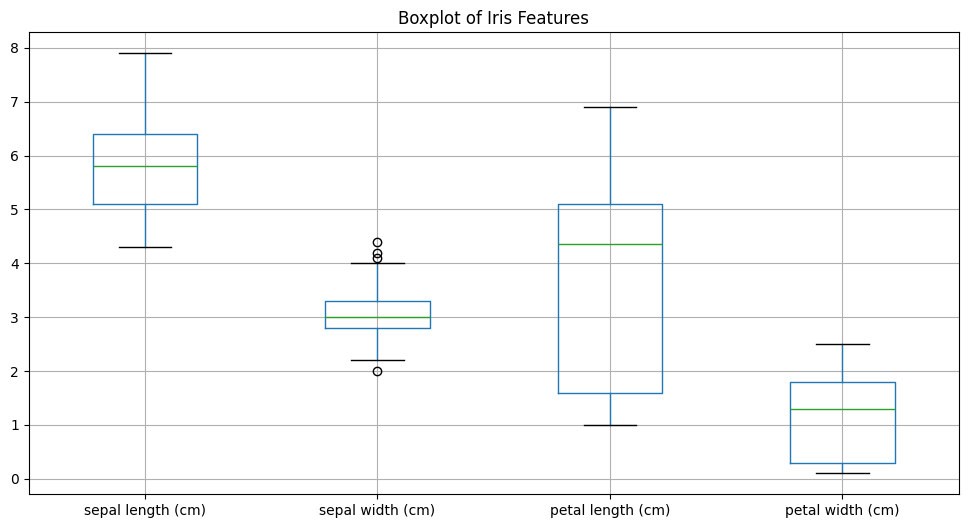

In [3]:
# Plot boxplots for each feature
plt.figure(figsize=(12,6))
df.drop("target", axis=1).boxplot()
plt.title("Boxplot of Iris Features")
plt.show()

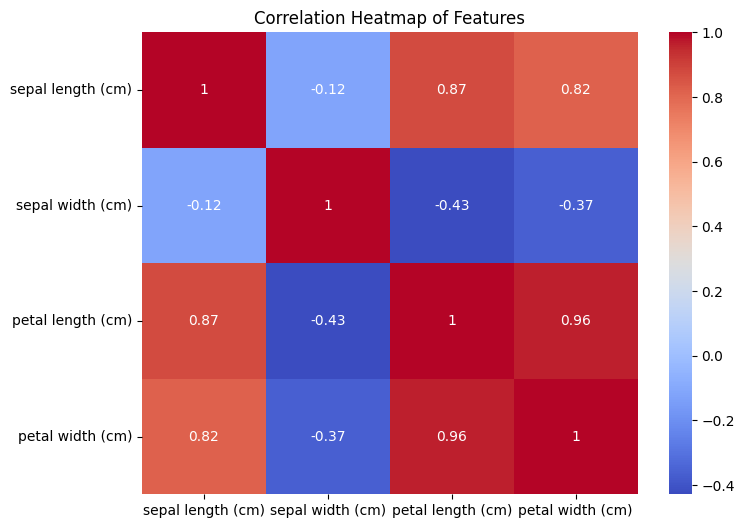

In [4]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("target",axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
Z = linkage(X_scaled, method='ward')


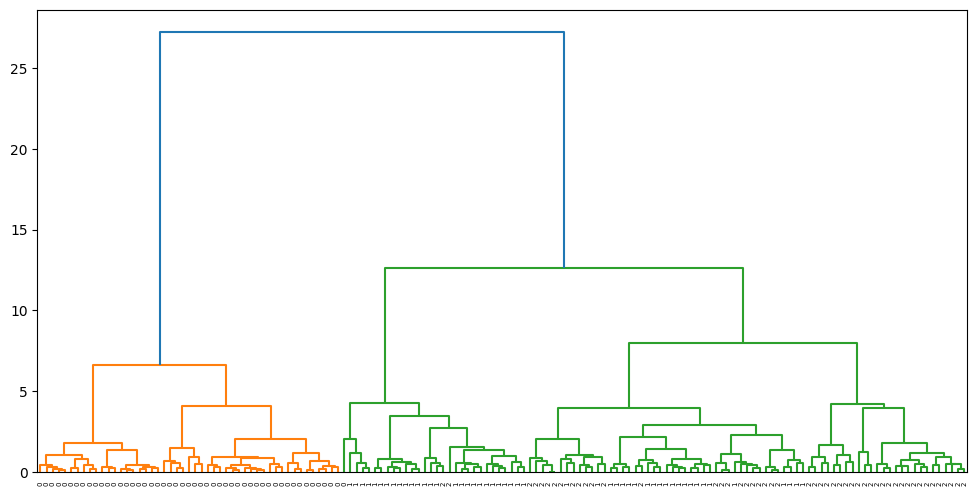

In [29]:
plt.figure(figsize=(12,6))
dendrogram(Z, labels=iris.target, leaf_rotation = 90)
plt.show()

In [30]:
cluster = fcluster(Z, t=3, criterion='maxclust')
df['cluster'] = cluster

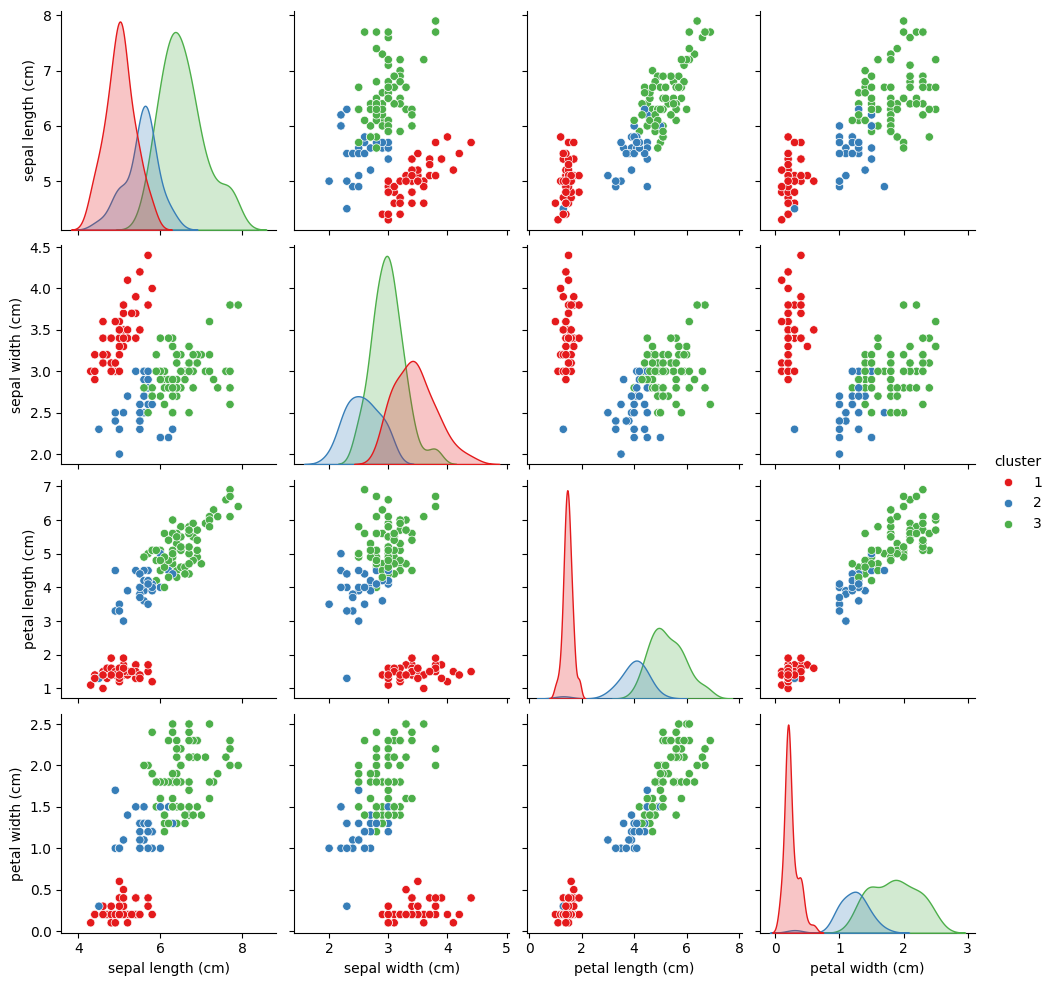

In [31]:
sns.pairplot(df, vars=iris.feature_names, palette='Set1', hue='cluster')
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Confusion matrix between real labels and clusters
cm = confusion_matrix(y, df['cluster'])
print("Confusion Matrix:\n", cm)

# Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y, df['cluster'])
print("Adjusted Rand Index:", ari)

Confusion Matrix:
 [[ 0 49  1  0]
 [ 0  0 27 23]
 [ 0  0  2 48]
 [ 0  0  0  0]]
Adjusted Rand Index: 0.6153229932145449


In [33]:
from sklearn.metrics import silhouette_score

sli = silhouette_score(X_scaled, df['cluster'])
print(sli)

0.4466890410285909
